In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error


C:\Users\hercd\AppData\Local\Temp\ipykernel_8544\1683341686.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\hercd\AppData\Local\Temp\ipykernel_8544\1209351260.py:1: SyntaxWarning: invalid escape sequence '\D'
  data = pd.read_csv("D:\Σπουδές\Μαθήματα-Σημειώσεις Data Science\Dissertation\Data\cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)


,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
data = data.dropna()

In [8]:
exog_vars_train = data[["humidity", "winddir", "temp", "cloudcover"]][: -168]
exog_vars_test = data[["humidity", "winddir", "temp", "cloudcover"]][-168: ]
x_train = data["solarradiation"][: -168]
x_test = data["solarradiation"][-168: ]
x_train.shape, x_test.shape, exog_vars_train.shape, exog_vars_test.shape

((21534,), (168,), (21534, 4), (168, 4))

In [9]:
exog_vars_test.isna().sum()

humidity      0
winddir       0
temp          0
cloudcover    0
dtype: int64

In [10]:
model_sarima = SARIMAX(x_train, 
                       exog_vars_train,
                       order=(5, 1, 2), 
                       seasonal_order=(1, 1, 1, 24))
model_sarima_fit = model_sarima.fit()
print(model_sarima_fit.summary())

c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting 

                                      SARIMAX Results                                       
Dep. Variable:                       solarradiation   No. Observations:                21534
Model:             SARIMAX(5, 1, 2)x(1, 1, [1], 24)   Log Likelihood             -123486.162
Date:                              Wed, 21 Aug 2024   AIC                         247000.323
Time:                                      20:41:51   BIC                         247111.990
Sample:                                           0   HQIC                        247036.729
                                            - 21534                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
humidity      -0.5568      0.085     -6.571      0.000      -0.723      -0.391
winddir        0.00

In [11]:
start = pd.Timestamp('2024-06-28 00:00:00')
end = pd.Timestamp('2024-07-04 23:00:00')

forecast = model_sarima_fit.get_forecast(steps=len(x_test), exog=exog_vars_test)
predictions = forecast.predicted_mean
predictions.index = x_test.index


c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\hercd\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


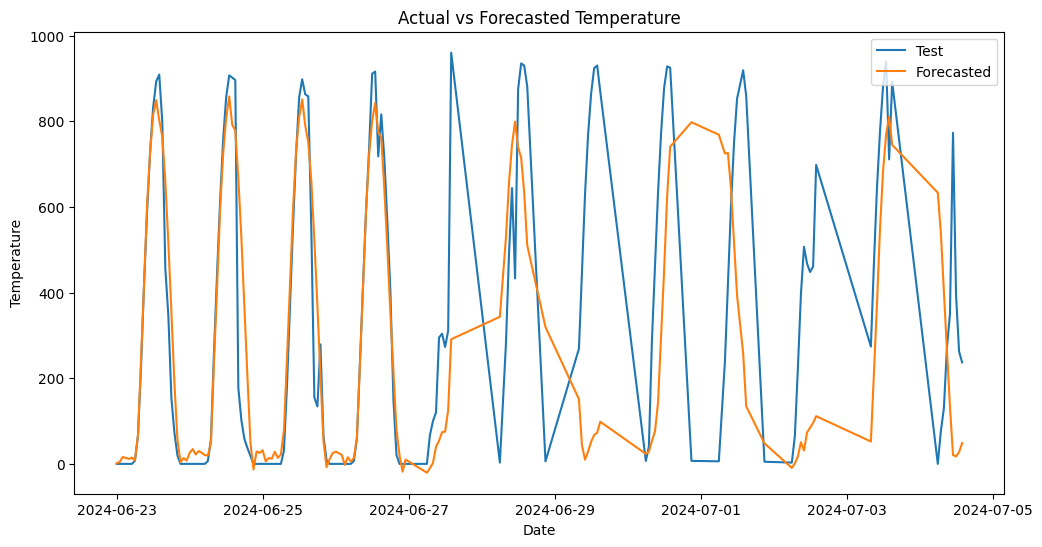

In [15]:
plt.figure(figsize=(12, 6))
#plt.plot(x_train, label='Train')
plt.plot(x_test, label='Test')
plt.plot(predictions, label='Forecasted')
plt.title('Actual vs Forecasted Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.legend()
plt.show()

In [13]:
mse = mean_squared_error(x_test, predictions)
ss_res = mse * len(x_test)
ss_tot = ((x_test - x_test.mean()) ** 2).sum()
r_squared = 1 - (ss_res / ss_tot)
print(f" Our model can explain the {round(r_squared, 10)* 100}% of total variability","\n","Root Mean Squared Error = ", np.sqrt(mse))

 Our model can explain the 36.09247949% of total variability 
 Root Mean Squared Error =  278.4054546097433


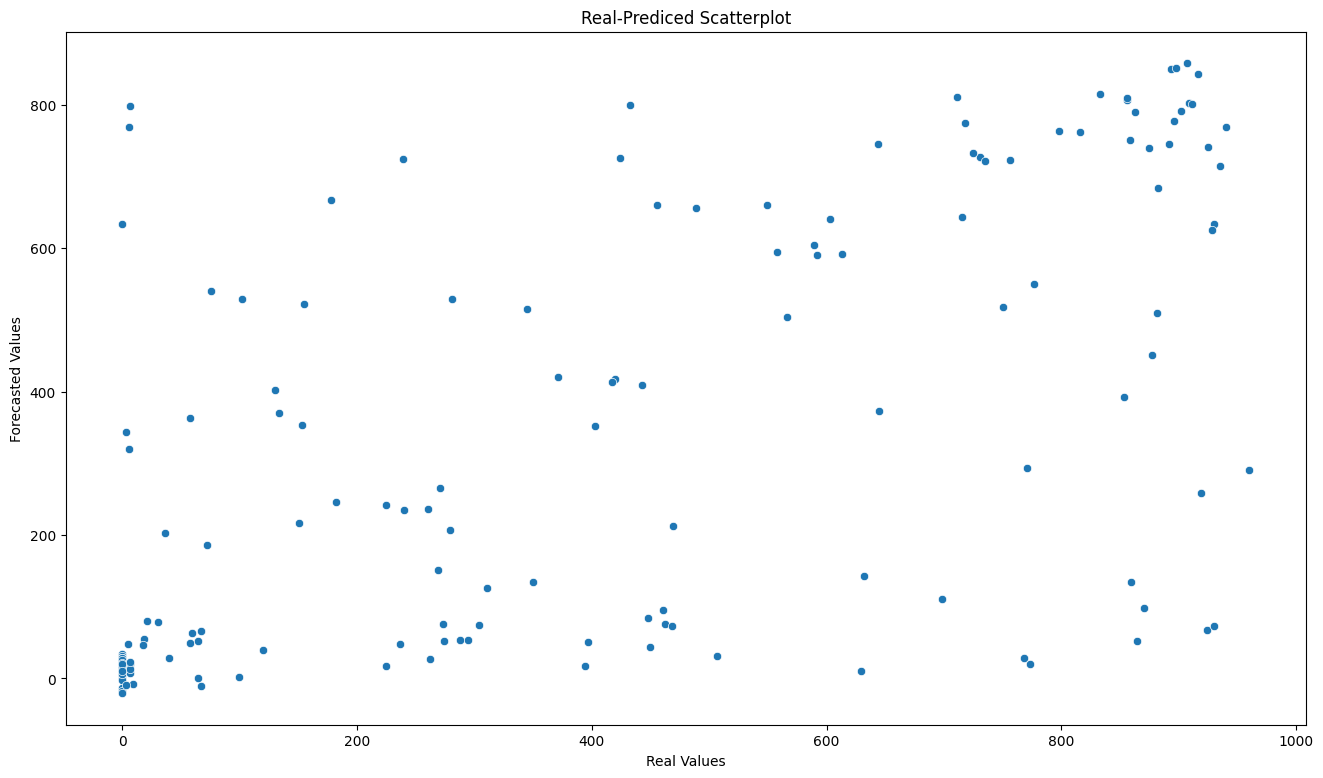

In [18]:
plt.figure(figsize= (16, 9))
sns.scatterplot(x = x_test, y = predictions)
plt.xlabel("Real Values")
plt.ylabel("Forecasted Values")
plt.title("Real-Prediced Scatterplot")
plt.show()